# matplotlibx / pltx Demo: Why Use It?

This notebook compares **true Matplotlib defaults** vs **pltx one-call styling** on the same data.

In [8]:
import numpy as np
import matplotlib.pyplot as mpl
import pltx.pyplot as pltx

In [9]:
# Shared datasets
x = np.linspace(0, 12, 500)
ys = [
    np.sin(x + 0.28 * i) * np.exp(-0.015 * i * x) + 0.08 * i
    for i in range(6)
]
labels = [f'Signal {i+1}' for i in range(len(ys))]

rng = np.random.default_rng(7)
hist_a = rng.normal(loc=0.0, scale=1.0, size=1200)
hist_b = rng.normal(loc=0.95, scale=1.20, size=1200)

## 1) Baseline: True Matplotlib defaults

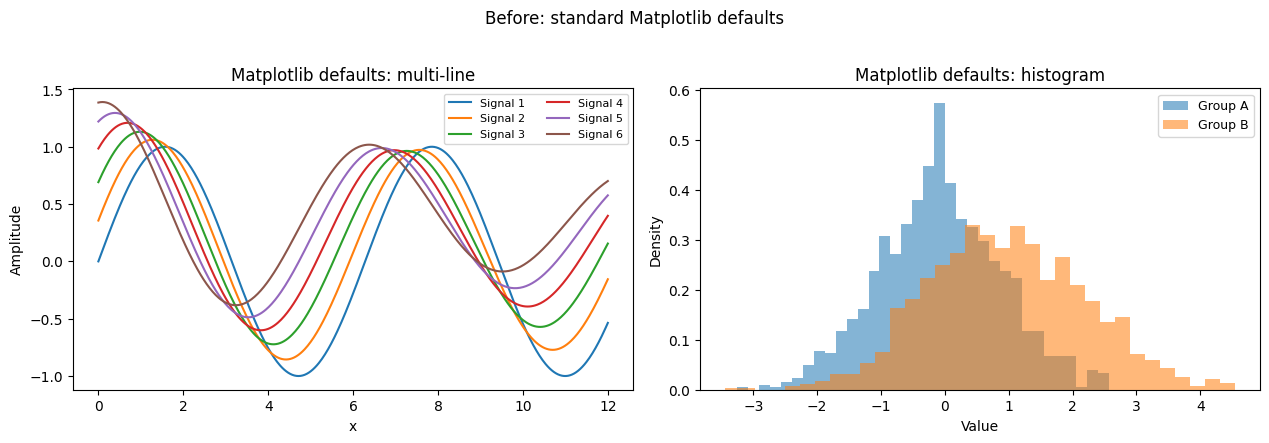

In [10]:
# IMPORTANT: force true defaults
mpl.rcdefaults()

fig, (ax1, ax2) = mpl.subplots(1, 2, figsize=(12.8, 4.3))

for y, label in zip(ys, labels):
    ax1.plot(x, y, label=label)
ax1.set_title('Matplotlib defaults: multi-line')
ax1.set_xlabel('x')
ax1.set_ylabel('Amplitude')
ax1.legend(ncol=2, fontsize=8)

ax2.hist(hist_a, bins=34, density=True, alpha=0.55, label='Group A')
ax2.hist(hist_b, bins=34, density=True, alpha=0.55, label='Group B')
ax2.set_title('Matplotlib defaults: histogram')
ax2.set_xlabel('Value')
ax2.set_ylabel('Density')
ax2.legend(fontsize=9)

fig.suptitle('Before: standard Matplotlib defaults', y=1.02)
fig.tight_layout()

## 2) pltx one-call setup

In [11]:
pltx.initialize_style(
    palette_name='pasqal',
    vary_linewidth=True,
    base_linewidth=2.0,
    linewidth_progression_factor=1.23
)

## 3) After: Same data with pltx

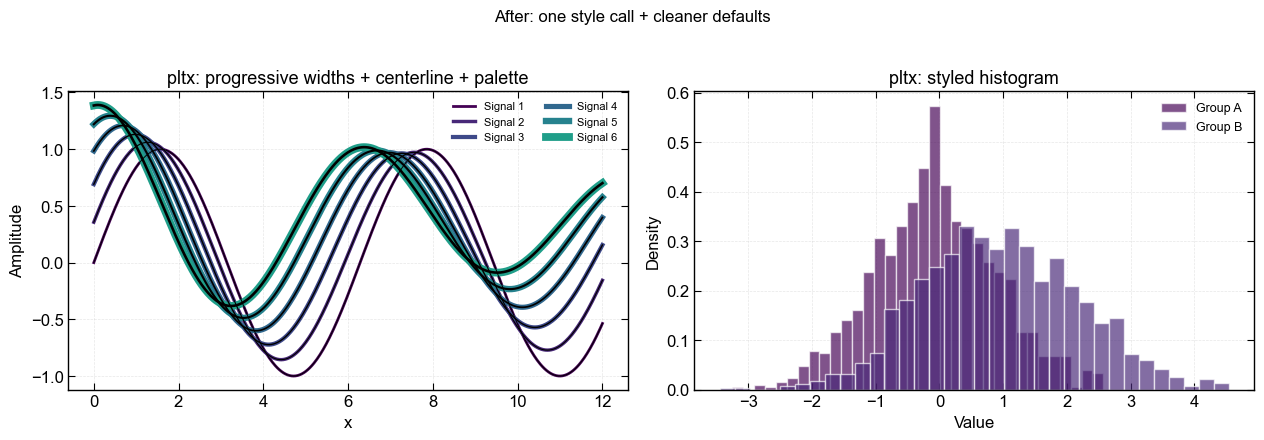

In [12]:
fig, (ax1, ax2) = pltx.subplots(1, 2, figsize=(12.8, 4.3))

for i, (y, label) in enumerate(zip(ys, labels)):
    pltx.plot_styled(
        x, y, ax=ax1, color_idx=i, label=label, centerline=True
    )
pltx.setup_axis(ax=ax1, xlabel='x', ylabel='Amplitude', grid=True)
ax1.set_title('pltx: progressive widths + centerline + palette')
ax1.legend(ncol=2, fontsize=8, frameon=False)

colors = [pltx.get_style().cycle_color(i) for i in range(2)]
pltx.hist_styled(
    hist_a, bins=34, density=True, ax=ax2,
    color=colors[0], alpha=0.68, edgecolor='white', label='Group A'
)
pltx.hist_styled(
    hist_b, bins=34, density=True, ax=ax2,
    color=colors[1], alpha=0.68, edgecolor='white', label='Group B'
)
pltx.setup_axis(ax=ax2, xlabel='Value', ylabel='Density', grid=True)
ax2.set_title('pltx: styled histogram')
ax2.legend(fontsize=9, frameon=False)

fig.suptitle('After: one style call + cleaner defaults', y=1.02)
fig.tight_layout()

## 4) Direct side-by-side (same multi-line data)

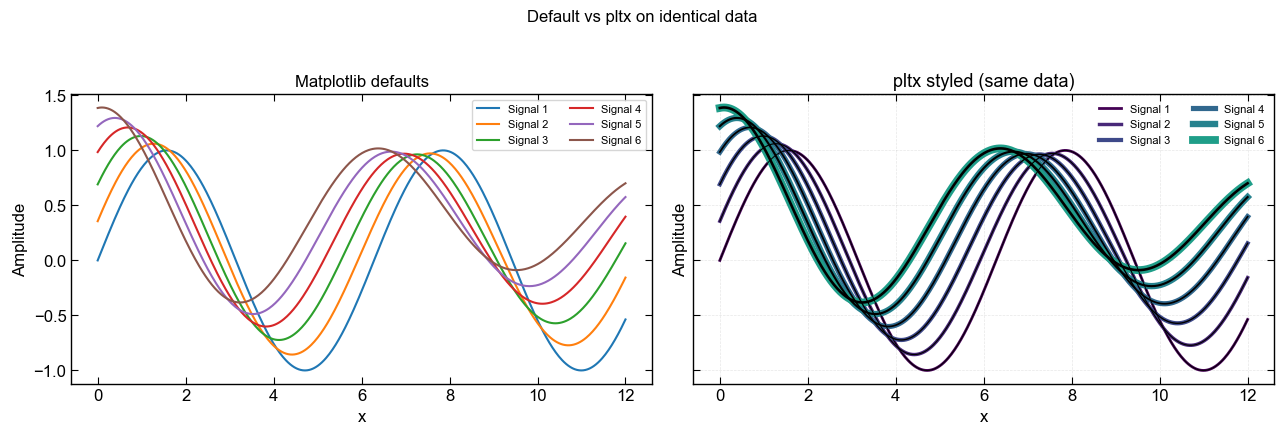

In [14]:
fig, (ax_left, ax_right) = mpl.subplots(1, 2, figsize=(13.0, 4.3), sharey=True)

mpl.rcdefaults()
for y, label in zip(ys, labels):
    ax_left.plot(x, y, label=label)
ax_left.set_title('Matplotlib defaults')
ax_left.set_xlabel('x')
ax_left.set_ylabel('Amplitude')
ax_left.legend(ncol=2, fontsize=8)

pltx.initialize_style(
    palette_name='pasqal',
    vary_linewidth=True,
    base_linewidth=2.0,
    linewidth_progression_factor=1.23
)
for i, (y, label) in enumerate(zip(ys, labels)):
    pltx.plot_styled(x, y, ax=ax_right, color_idx=i, centerline=True, label=label)
pltx.setup_axis(ax=ax_right, xlabel='x', ylabel='Amplitude', grid=True)
ax_right.set_title('pltx styled (same data)')
ax_right.legend(ncol=2, fontsize=8, frameon=False)

fig.suptitle('Default vs pltx on identical data', y=1.02)
fig.tight_layout()

## 5) Accessibility check in grayscale

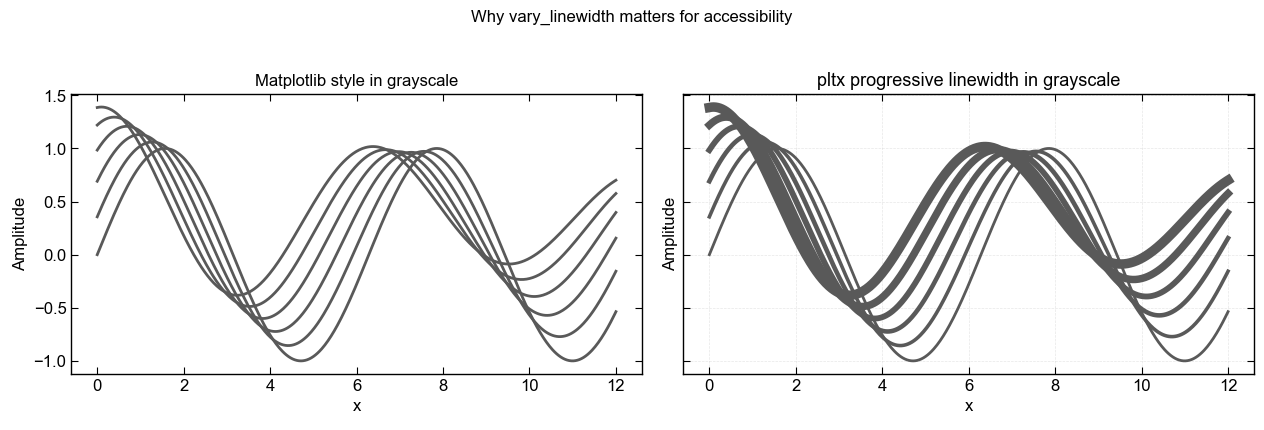

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/i.sokolov/Code/pltx/.venv/lib/python3.10/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/Users/i.sokolov/Code/pltx/.venv/lib/python3.10/site-packages/ipykernel/kernelbase.py", line 584, in shell_channel_thread_main
    _, msg2 = self.session.feed_identities(msg, copy=False)
  File "/Users/i.sokolov/Code/pltx/.venv/lib/python3.10/site-packages/jupyter_client/session.py", line 998, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
Bad pipe message: %s [b"\x1a\x96\xb1\xef0w4\x07\x91p\xd0\x03\xd8\xf3\x08+V\x8b \x8eCZ'\xf3\xaf\xfd\x89\xcb\x1b\xf1C\x13\xd6\xc5\xd8\x01/\xca\xd3\x99^\rH\xfe\xa5v\t\x8e\xa9C\xcc\x00$\x13\x01\x13\x02\x13\x03\xc0/\xc0+\xc00\xc0,\xc0'\xcc\xa9\xcc\xa8\xc0\t\xc0\x13\xc0\n\xc0\x14\x00\x9c\x00\x9d\x00/\x005\x01\x00\x00p\x00\x17\x00\x00\xff\x01\x00\x01\x00\x00\n\x00\x08\x00\x06\x00\x1d\x0

In [ ]:
fig, (ax1, ax2) = mpl.subplots(1, 2, figsize=(12.8, 4.2), sharey=True)

mpl.rcdefaults()
for y in ys:
    ax1.plot(x, y, color='0.35', linewidth=2)
ax1.set_title('Matplotlib style in grayscale')
ax1.set_xlabel('x')
ax1.set_ylabel('Amplitude')

pltx.initialize_style(vary_linewidth=True, base_linewidth=1.8, linewidth_progression_factor=1.28)
for i, y in enumerate(ys):
    pltx.plot_styled(x, y, color='0.35', color_idx=i, ax=ax2)
pltx.setup_axis(ax=ax2, xlabel='x', ylabel='Amplitude', grid=True)
ax2.set_title('pltx progressive linewidth in grayscale')

fig.suptitle('Why vary_linewidth matters for accessibility', y=1.02)
fig.tight_layout()